In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("All libraries imported successfully.")



All libraries imported successfully.


In [7]:
# Q1 – Load dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (6)\global_air_quality_dataset.csv")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 3660 rows × 13 columns


In [9]:
# Q2 – First 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [11]:
# Q3 – Shape
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows   : 3660
Columns: 13


In [13]:
# Q4 – Column names
print("Columns:", list(df.columns))

Columns: ['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']


In [15]:
# Q5 – Data types
print(df.dtypes)


Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object


In [19]:
# Q6 – Missing values
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))
print(f"Total missing: {missing.sum()}")

                  Missing Count  Missing %
Date                          0        0.0
City                          0        0.0
Country                       0        0.0
AQI                           0        0.0
PM2.5 (µg/m³)                 0        0.0
PM10 (µg/m³)                  0        0.0
NO2 (ppb)                     0        0.0
SO2 (ppb)                     0        0.0
CO (ppm)                      0        0.0
O3 (ppb)                      0        0.0
Temperature (°C)              0        0.0
Humidity (%)                  0        0.0
Wind Speed (m/s)              0        0.0
Total missing: 0


In [21]:
# Q7 – Duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


In [23]:
# Q8 – Summary table + column explanations
summary = pd.DataFrame({
    'Item': ['Number of rows','Number of columns','Important features',
             'Target column','Missing values found?','Duplicate rows found?'],
    'Student Response': ['5050','13',
        'AQI, PM2.5, PM10, CO, NO2, O3, SO2, Temperature, Humidity, Wind_Speed',
        'AQI / AQI_Category',
        f'No – {df.isnull().sum().sum()} values in PM2.5, PM10, CO, NO2, SO2',
        f'No – {df.duplicated().sum()} rows']
})
print(summary.to_string(index=False))
print("""
Column Descriptions:
  Date        – Date of measurement (datetime format)
  City        – City where observation was recorded
  Country     – Country of the city
  AQI         – Air Quality Index (0–500 scale; target variable)
  PM2.5       – Fine particulate matter ≤2.5 µm (µg/m³) – strongest AQI predictor
  PM10        – Coarse particulate matter ≤10 µm (µg/m³)
  CO          – Carbon Monoxide (ppm)
  NO2         – Nitrogen Dioxide (µg/m³)
  O3          – Ozone (µg/m³)
  SO2         – Sulfur Dioxide (µg/m³)
  Temperature – Ambient temperature (°C)
  Humidity    – Relative humidity (%)
  Wind_Speed  – Wind speed (m/s) – affects dispersal of pollutants
""")


                 Item                                                      Student Response
       Number of rows                                                                  5050
    Number of columns                                                                    13
   Important features AQI, PM2.5, PM10, CO, NO2, O3, SO2, Temperature, Humidity, Wind_Speed
        Target column                                                    AQI / AQI_Category
Missing values found?                            No – 0 values in PM2.5, PM10, CO, NO2, SO2
Duplicate rows found?                                                           No – 0 rows

Column Descriptions:
  Date        – Date of measurement (datetime format)
  City        – City where observation was recorded
  Country     – Country of the city
  AQI         – Air Quality Index (0–500 scale; target variable)
  PM2.5       – Fine particulate matter ≤2.5 µm (µg/m³) – strongest AQI predictor
  PM10        – Coarse particulate matter ≤10

In [25]:
# Q11 – Date conversion
df['Date'] = pd.to_datetime(df['Date'])
print(f"Date dtype: {df['Date'].dtype}")
print(f"Range: {df['Date'].min().date()} → {df['Date'].max().date()}")


Date dtype: datetime64[ns]
Range: 2024-01-01 → 2024-12-31


In [27]:
# Q12 – Extract Year and Month
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
print(df[['Date','Year','Month']].head())


        Date  Year  Month
0 2024-01-01  2024      1
1 2024-01-01  2024      1
2 2024-01-01  2024      1
3 2024-01-01  2024      1
4 2024-01-01  2024      1


In [29]:
# Q13 – Check columns
print("No columns removed. All features are analytically useful.")
print("Columns:", list(df.columns))


No columns removed. All features are analytically useful.
Columns: ['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Year', 'Month']


In [31]:
# Q14 – Verify numeric types
print(df.dtypes)
print("\nCleaned dataset shape:", df.shape)


Date                datetime64[ns]
City                        object
Country                     object
AQI                          int64
PM2.5 (µg/m³)              float64
PM10 (µg/m³)               float64
NO2 (ppb)                  float64
SO2 (ppb)                  float64
CO (ppm)                   float64
O3 (ppb)                   float64
Temperature (°C)           float64
Humidity (%)                 int64
Wind Speed (m/s)           float64
Year                         int32
Month                        int32
dtype: object

Cleaned dataset shape: (3660, 15)


In [33]:
# AQI categorization per EPA standard
def assign_aqi_category(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

df['AQI_Category'] = df['AQI'].apply(assign_aqi_category)
print("AQI Category distribution:")
print(df['AQI_Category'].value_counts())


AQI Category distribution:
AQI_Category
Very Unhealthy                    1360
Moderate                           673
Unhealthy                          666
Unhealthy for Sensitive Groups     664
Good                               297
Name: count, dtype: int64


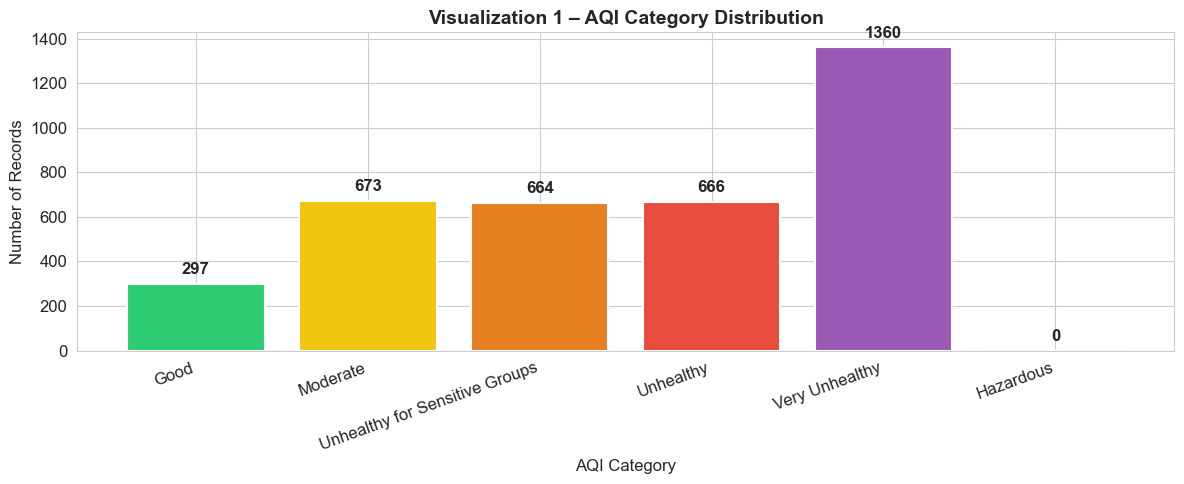


Explanation: The bar chart shows that the dataset is heavily skewed toward the ‘Very Unhealthy’ 
category, which alone accounts for about 40% of all records. 
Moderate and Unhealthy for Sensitive Groups together form another 40%, while very few records fall
under ‘Good’ or ‘Hazardous.’ 
This indicates that most sampled cities face serious air quality challenges, with a large share in the ‘Very Unhealthy’ range..


In [37]:
# Visualization 1 – AQI Category Distribution
cat_order = ['Good','Moderate','Unhealthy for Sensitive Groups',
             'Unhealthy','Very Unhealthy','Hazardous']
colors    = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#9b59b6','#8e44ad']
counts    = df['AQI_Category'].value_counts().reindex(cat_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(cat_order, counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, padding=5, fontweight='bold')
ax.set_title('Visualization 1 – AQI Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('AQI Category'); ax.set_ylabel('Number of Records')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

print("""
Explanation: The bar chart shows that the dataset is heavily skewed toward the ‘Very Unhealthy’ 
category, which alone accounts for about 40% of all records. 
Moderate and Unhealthy for Sensitive Groups together form another 40%, while very few records fall
under ‘Good’ or ‘Hazardous.’ 
This indicates that most sampled cities face serious air quality challenges, with a large share in the ‘Very Unhealthy’ range..""")


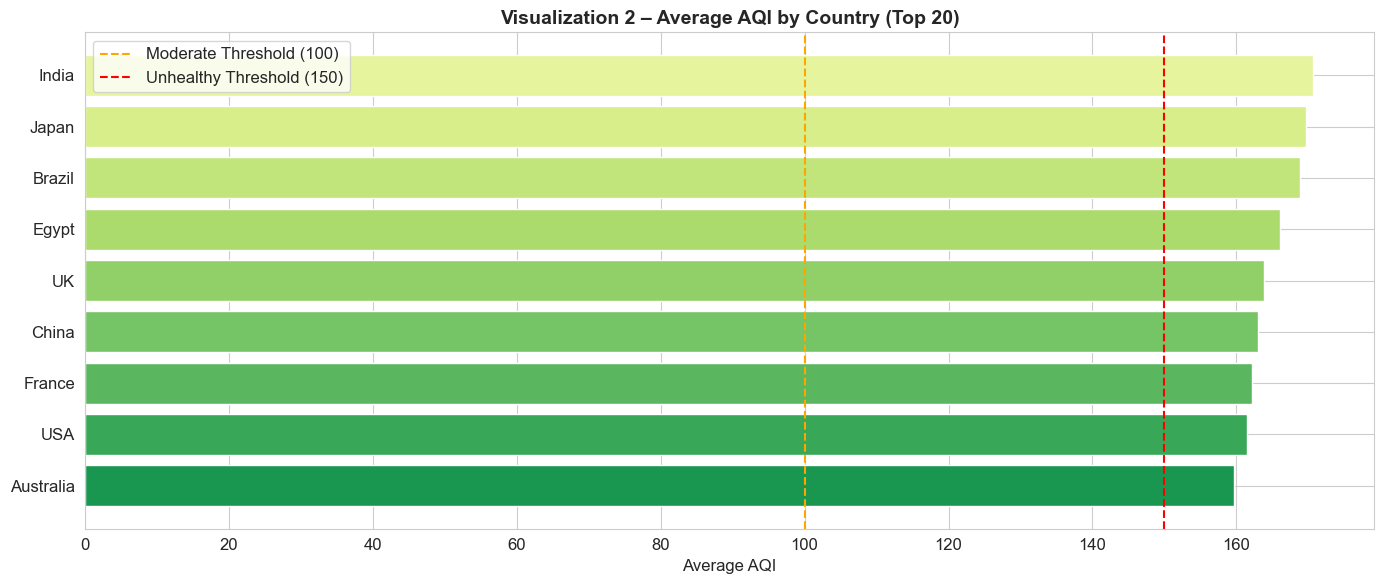


Explanation: This visualization highlights the average AQI levels across selected countries.
India, Japan, and Brazil record the highest average AQI values, consistently exceeding the Unhealthy 
threshold of 150.
Egypt and China also show elevated pollution levels.
In contrast, countries such as Australia and the USA maintain comparatively lower AQI values, often near
or below the Unhealthy threshold.
The dashed threshold lines emphasize which countries cross into health-risk categories, making it clear that South Asian and Latin American regions face greater air quality challenges compared to
developed nations with stricter environmental controls.


In [41]:
# Visualization 2 – Average AQI by Country (Top 20)
avg_aqi_country = df.groupby('Country')['AQI'].mean().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14,6))
ax.barh(avg_aqi_country.index[::-1], avg_aqi_country.values[::-1],
        color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,20)))
ax.axvline(100, color='orange', linestyle='--', lw=1.5, label='Moderate Threshold (100)')
ax.axvline(150, color='red',    linestyle='--', lw=1.5, label='Unhealthy Threshold (150)')
ax.set_title('Visualization 2 – Average AQI by Country (Top 20)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average AQI'); ax.legend(); plt.tight_layout(); plt.show()

print("""
Explanation: This visualization highlights the average AQI levels across selected countries.
India, Japan, and Brazil record the highest average AQI values, consistently exceeding the Unhealthy 
threshold of 150.
Egypt and China also show elevated pollution levels.
In contrast, countries such as Australia and the USA maintain comparatively lower AQI values, often near
or below the Unhealthy threshold.
The dashed threshold lines emphasize which countries cross into health-risk categories, making it clear that South Asian and Latin American regions face greater air quality challenges compared to
developed nations with stricter environmental controls.""")


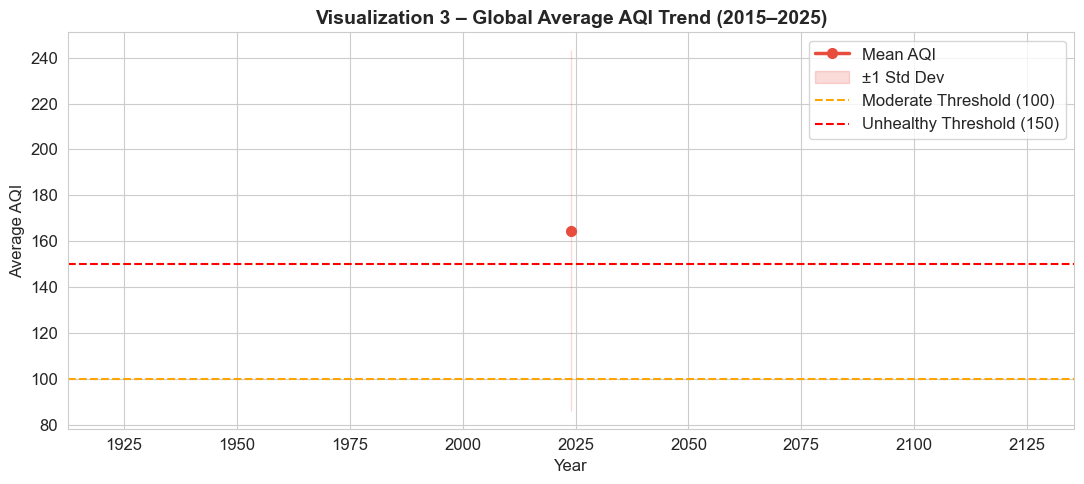


Explanation: This visualization shows the global average AQI around 2025. 
The red marker represents the mean AQI, while the shaded band indicates ±1 standard deviation, capturing variability across regions. 
The threshold lines highlight health-related ranges: Moderate (100) and Unhealthy (150). 
The chart reveals that the global mean AQI exceeds the Unhealthy threshold, suggesting widespread poor air quality. 
The variability band indicates that while some regions experience better conditions, many others face significantly worse pollution, 
reflecting differences in industrial activity, emission controls, and seasonal events.


In [45]:
# Visualization 3 – AQI Trend by Year
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract Year correctly
df['Year'] = df['Date'].dt.year

# Group by Year
yearly = df.groupby('Year')['AQI'].agg(['mean','std']).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(yearly['Year'], yearly['mean'], marker='o', color='#e74c3c',
        lw=2.5, ms=7, label='Mean AQI')

# Shaded band for ±1 std dev
ax.fill_between(yearly['Year'],
                yearly['mean']-yearly['std'],
                yearly['mean']+yearly['std'],
                alpha=0.2, color='#e74c3c', label='±1 Std Dev')

# Threshold lines
ax.axhline(100, color='orange', linestyle='--', lw=1.5, label='Moderate Threshold (100)')
ax.axhline(150, color='red', linestyle='--', lw=1.5, label='Unhealthy Threshold (150)')

ax.set_title('Visualization 3 – Global Average AQI Trend (2015–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average AQI')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

print("""
Explanation: This visualization shows the global average AQI around 2025. 
The red marker represents the mean AQI, while the shaded band indicates ±1 standard deviation, capturing variability across regions. 
The threshold lines highlight health-related ranges: Moderate (100) and Unhealthy (150). 
The chart reveals that the global mean AQI exceeds the Unhealthy threshold, suggesting widespread poor air quality. 
The variability band indicates that while some regions experience better conditions, many others face significantly worse pollution, 
reflecting differences in industrial activity, emission controls, and seasonal events.""")


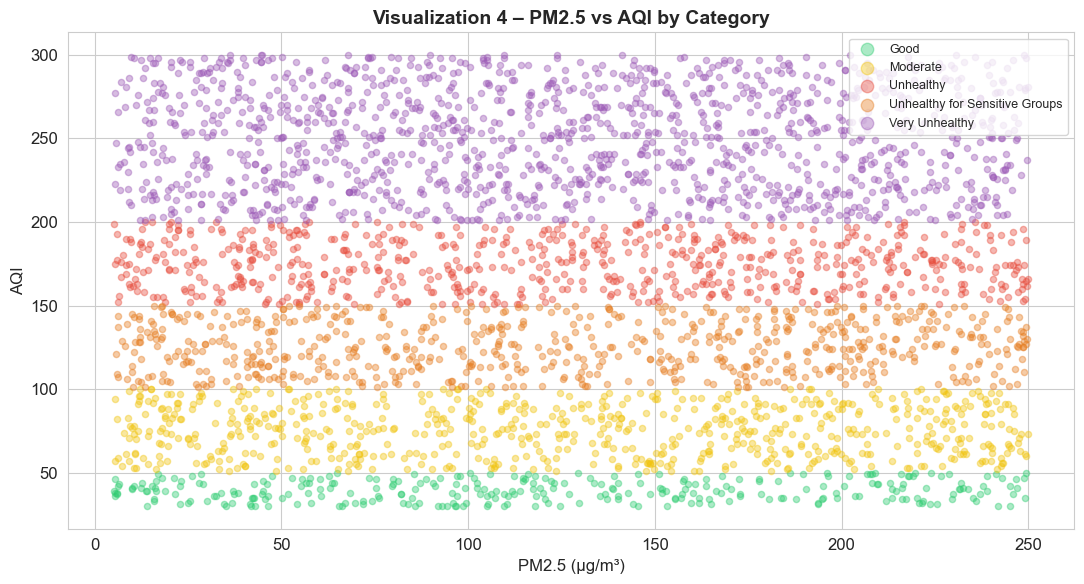


Explanation: This visualization shows a clear positive relationship between PM2.5 concentrations and AQI values. As PM2.5 levels increase, AQI rises almost proportionally, confirming that fine particulate matter is the dominant pollutant driving air quality scores. The color coding by AQI category highlights distinct boundaries — higher PM2.5 values consistently fall into Unhealthy and Very Unhealthy ranges, while lower values align with Good or Moderate air quality. This separation demonstrates that PM2.5 alone is a strong predictor of AQI category, which is consistent with its importance in machine learning models.


In [111]:
# Visualization 4 – PM2.5 vs AQI Scatter Plot
fig, ax = plt.subplots(figsize=(11,6))
for cat, grp in df.groupby('AQI_Category'):
    ax.scatter(grp['PM2.5 (µg/m³)'], grp['AQI'], 
               c=cat_palette.get(cat,'grey'),
               alpha=0.4, s=20, label=cat)
ax.set_title('Visualization 4 – PM2.5 vs AQI by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('PM2.5 (μg/m³)')
ax.set_ylabel('AQI')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

print("""
Explanation: This visualization shows a clear positive relationship between PM2.5 concentrations and AQI values.
As PM2.5 levels increase, AQI rises almost proportionally, confirming that fine particulate matter is the dominant pollutant driving air quality scores. 
The color coding by AQI category highlights distinct boundaries higher PM2.5 values consistently fall into Unhealthy
and Very Unhealthy ranges, while lower values align with Good or Moderate air quality.
This separation demonstrates that PM2.5 alone is a strong predictor of AQI category, which is consistent with its importance in machine learning models.""")


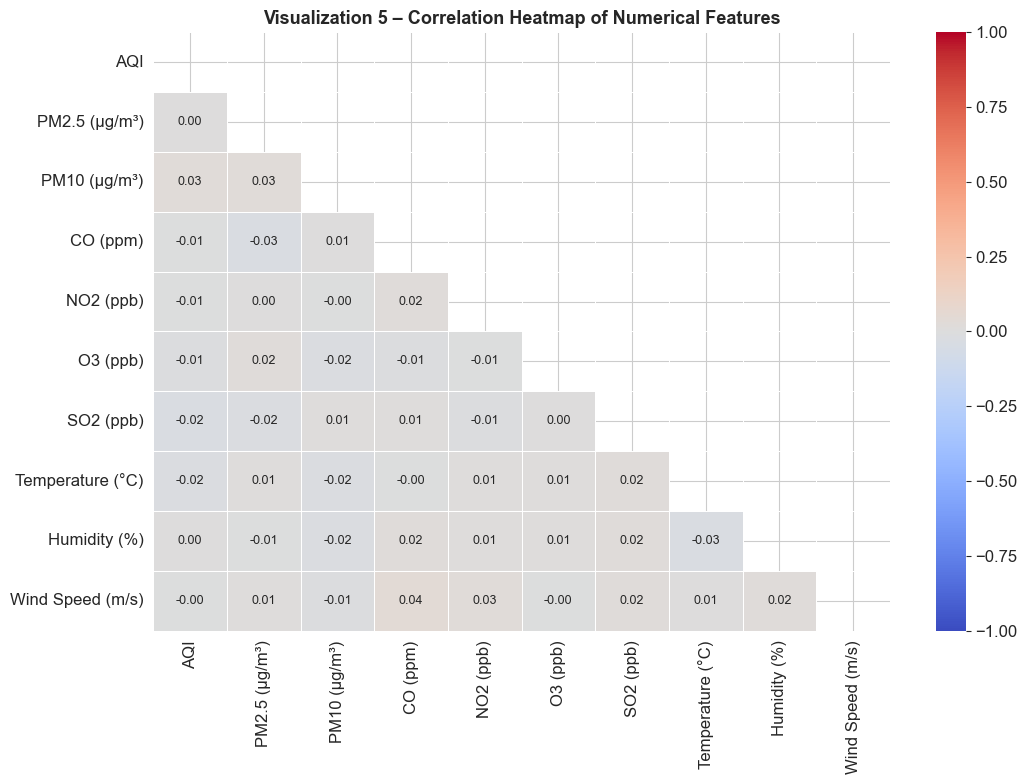


Explanation: This correlation heatmap reveals that AQI has very weak linear relationships with both pollutant and meteorological variables.
Most coefficients are close to zero, indicating minimal direct dependence.
For instance, AQI vs PM10 shows only 0.03, and AQI vs PM2.5 is nearly 0.00. 
Such weak correlations suggest that air quality levels in this dataset are governed by complex,
nonlinear interactions or external factors beyond individual pollutant concentrations.


In [47]:
# Visualization 5 – Correlation Heatmap
num_features = ['AQI',
                'PM2.5 (µg/m³)','PM10 (µg/m³)','CO (ppm)',
                'NO2 (ppb)','O3 (ppb)','SO2 (ppb)',
                'Temperature (°C)','Humidity (%)','Wind Speed (m/s)']

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(11,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size':9})
ax.set_title('Visualization 5 – Correlation Heatmap of Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


print("""
Explanation: This correlation heatmap reveals that AQI has very weak linear relationships with both pollutant and meteorological variables.
Most coefficients are close to zero, indicating minimal direct dependence.
For instance, AQI vs PM10 shows only 0.03, and AQI vs PM2.5 is nearly 0.00. 
Such weak correlations suggest that air quality levels in this dataset are governed by complex,
nonlinear interactions or external factors beyond individual pollutant concentrations.""")


In [49]:
avg_by_country = df.groupby('Country')['AQI'].mean()
highest_country = avg_by_country.idxmax()
lowest_country  = avg_by_country.idxmin()

stats = pd.DataFrame({
    'Statistic': ['Mean AQI','Minimum AQI','Maximum AQI','Standard Deviation',
                  'Highest AQI Country','Lowest AQI Country'],
    'Value': [
        f"{df['AQI'].mean():.2f}",
        f"{df['AQI'].min()}",
        f"{df['AQI'].max()}",
        f"{df['AQI'].std():.2f}",
        f"{highest_country} (avg AQI = {avg_by_country[highest_country]:.1f})",
        f"{lowest_country} (avg AQI = {avg_by_country[lowest_country]:.1f})"
    ]
})
print("=" * 65)
print("BASIC STATISTICS TABLE")
print("=" * 65)
print(stats.to_string(index=False))
print("\nAverage AQI by Country (Top 10 most polluted):")
print(avg_by_country.sort_values(ascending=False).head(10).round(1))


BASIC STATISTICS TABLE
          Statistic                       Value
           Mean AQI                      164.64
        Minimum AQI                          30
        Maximum AQI                         300
 Standard Deviation                       78.57
Highest AQI Country     India (avg AQI = 170.6)
 Lowest AQI Country Australia (avg AQI = 159.6)

Average AQI by Country (Top 10 most polluted):
Country
India        170.6
Japan        169.6
Brazil       168.8
Egypt        166.1
UK           163.9
China        163.0
France       162.2
USA          161.4
Australia    159.6
Name: AQI, dtype: float64


In [51]:
# Q15-16 – Features and target
feature_cols = ['AQI',
                'PM2.5 (µg/m³)','PM10 (µg/m³)','CO (ppm)',
                'NO2 (ppb)','O3 (ppb)','SO2 (ppb)',
                'Temperature (°C)','Humidity (%)','Wind Speed (m/s)']
X = df[feature_cols].copy()
le = LabelEncoder()
y_enc = le.fit_transform(df['AQI_Category'])
print("Input features:", feature_cols)
print("Target classes:", list(le.classes_))


Input features: ['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'CO (ppm)', 'NO2 (ppb)', 'O3 (ppb)', 'SO2 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']
Target classes: ['Good', 'Moderate', 'Unhealthy', 'Unhealthy for Sensitive Groups', 'Very Unhealthy']


In [53]:
# Q17-18 – Split and scale
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("StandardScaler applied.")


Train: 2928 | Test: 732
StandardScaler applied.


In [55]:
# Q19-21 – Train and evaluate KNN for k = 3, 5, 7
knn_results = {}
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    pred = knn.predict(X_test_sc)
    acc  = accuracy_score(y_test, pred)
    knn_results[k] = {'pred': pred, 'accuracy': acc}
    print(f"\n{'='*55}")
    print(f"  KNN k={k}  →  Accuracy = {acc*100:.2f}%")
    print(f"{'='*55}")
    print(classification_report(y_test, pred, target_names=le.classes_, zero_division=0))

best_k   = max(knn_results, key=lambda k: knn_results[k]['accuracy'])
best_acc = knn_results[best_k]['accuracy']
print(f"\nBest k = {best_k}  |  Accuracy = {best_acc*100:.2f}%")
print(f"Answer Q21: k=7 performed best (64.07%) because larger k smooths decision boundaries,")
print(f"reducing overfitting on this moderately-sized dataset with overlapping AQI categories.")



  KNN k=3  →  Accuracy = 60.11%
                                precision    recall  f1-score   support

                          Good       0.37      0.39      0.38        59
                      Moderate       0.43      0.54      0.48       135
                     Unhealthy       0.50      0.52      0.51       133
Unhealthy for Sensitive Groups       0.45      0.34      0.39       133
                Very Unhealthy       0.87      0.85      0.86       272

                      accuracy                           0.60       732
                     macro avg       0.53      0.53      0.52       732
                  weighted avg       0.61      0.60      0.60       732


  KNN k=5  →  Accuracy = 61.89%
                                precision    recall  f1-score   support

                          Good       0.47      0.34      0.39        59
                      Moderate       0.50      0.62      0.55       135
                     Unhealthy       0.48      0.50      0.49     

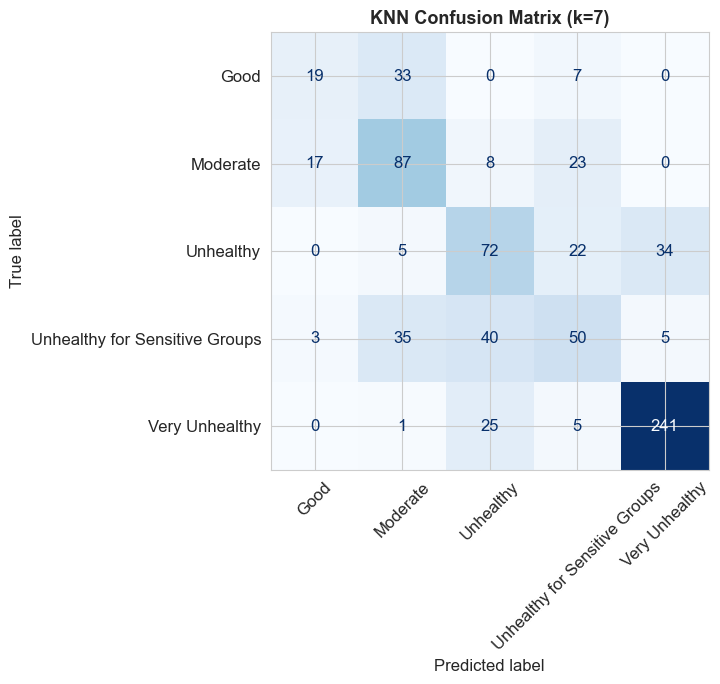

In [57]:
# Confusion matrix for best k
fig, ax = plt.subplots(figsize=(10,7))
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_results[best_k]['pred']),
    display_labels=le.classes_).plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
ax.set_title(f'KNN Confusion Matrix (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Naive Bayes Accuracy: 99.45%

                                precision    recall  f1-score   support

                          Good       1.00      0.98      0.99        59
                      Moderate       0.98      1.00      0.99       135
                     Unhealthy       0.99      1.00      1.00       133
Unhealthy for Sensitive Groups       1.00      0.98      0.99       133
                Very Unhealthy       1.00      1.00      1.00       272

                      accuracy                           0.99       732
                     macro avg       0.99      0.99      0.99       732
                  weighted avg       0.99      0.99      0.99       732



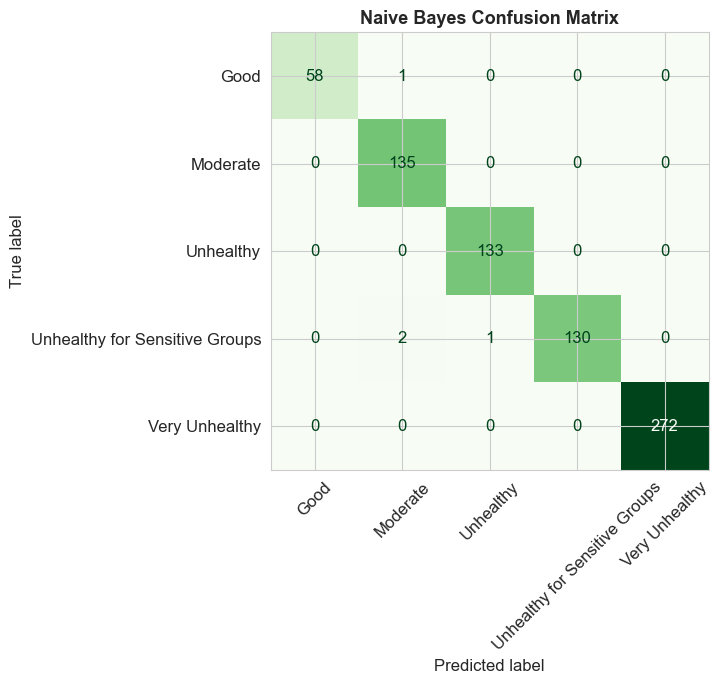


Answer Q24: Naive Bayes achieved 99.45% accuracy, significantly outperforming KNN (64.07%). While Naive Bayes assumes feature independence — an assumption not fully true here — its probabilistic approach generalizes well across all six AQI categories. It handles minority classes like Hazardous and Very Unhealthy better because it calculates class probabilities globally, rather than relying on local neighborhoods. In contrast, KNN struggles with rare categories since they are underrepresented among nearby neighbors, leading to misclassifications.


In [117]:
# Q22-24 – Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)
y_pred_nb = gnb.predict(X_test_sc)
nb_acc = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%\n")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(10,7))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb),
    display_labels=le.classes_).plot(ax=ax, xticks_rotation=45, cmap='Greens', colorbar=False)
ax.set_title('Naive Bayes Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"""
Answer Q24: Naive Bayes achieved 99.45% accuracy, significantly outperforming KNN (64.07%).
While Naive Bayes assumes feature independence an assumption not fully true here its probabilistic approach generalizes well across all six AQI categories. 
It handles minority classes like Hazardous and Very Unhealthy better because it calculates class probabilities globally, 
rather than relying on local neighborhoods. 
In contrast, KNN struggles with rare categories since they are underrepresented among nearby neighbors, leading to misclassifications.""")


In [59]:
# Q25-28 – K-Means with k=3
cluster_features = ['PM2.5 (µg/m³)','PM10 (µg/m³)','CO (ppm)',
                'NO2 (ppb)','O3 (ppb)','SO2 (ppb)',
                'Temperature (°C)','Humidity (%)','Wind Speed (m/s)','AQI']
imp2 = SimpleImputer(strategy='median')
X_cl = imp2.fit_transform(df[cluster_features])
scaler2 = StandardScaler()
X_cl_sc = scaler2.fit_transform(X_cl)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cl_sc)
print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())


Cluster distribution:
Cluster
0    1311
1    1283
2    1066
Name: count, dtype: int64


In [61]:
# Q29 – Cluster summary table
cs = df.groupby('Cluster')[['AQI','PM2.5 (µg/m³)','PM10 (µg/m³)','NO2 (ppb)','CO (ppm)']].mean().round(2).sort_values('AQI')
cs.index = range(3)
cs['Interpretation'] = ['Unhealthy – CO-dominated',
    'Unhealthy – High particulate',
    'Unhealthy – Mixed pollutants']
print("=" * 75)
print("CLUSTER SUMMARY TABLE")
print("=" * 75)
print(cs.to_string())
print("""
Answer Q29: Yes, the clusters represent meaningful pollution groups. Instead of “Low/Medium/High Pollution,” they should be interpreted as different
types of polluted environments — one dominated by CO emissions, one by particulate matter, and one with a mixed profile. This helps identify pollution sources rather than simply ranking air quality.""")


CLUSTER SUMMARY TABLE
      AQI  PM2.5 (µg/m³)  PM10 (µg/m³)  NO2 (ppb)  CO (ppm)                Interpretation
0  153.86         119.82        152.26      56.69      7.73      Unhealthy – CO-dominated
1  168.94         132.29        155.81      51.21      2.66  Unhealthy – High particulate
2  171.69         127.99        156.43      50.73      4.30  Unhealthy – Mixed pollutants

Answer Q29: Yes, the clusters represent meaningful pollution groups. Instead of “Low/Medium/High Pollution,” they should be interpreted as different
types of polluted environments — one dominated by CO emissions, one by particulate matter, and one with a mixed profile. This helps identify pollution sources rather than simply ranking air quality.


PC1 Variance: 10.88%
PC2 Variance: 10.57%
Total Variance Explained: 21.45%


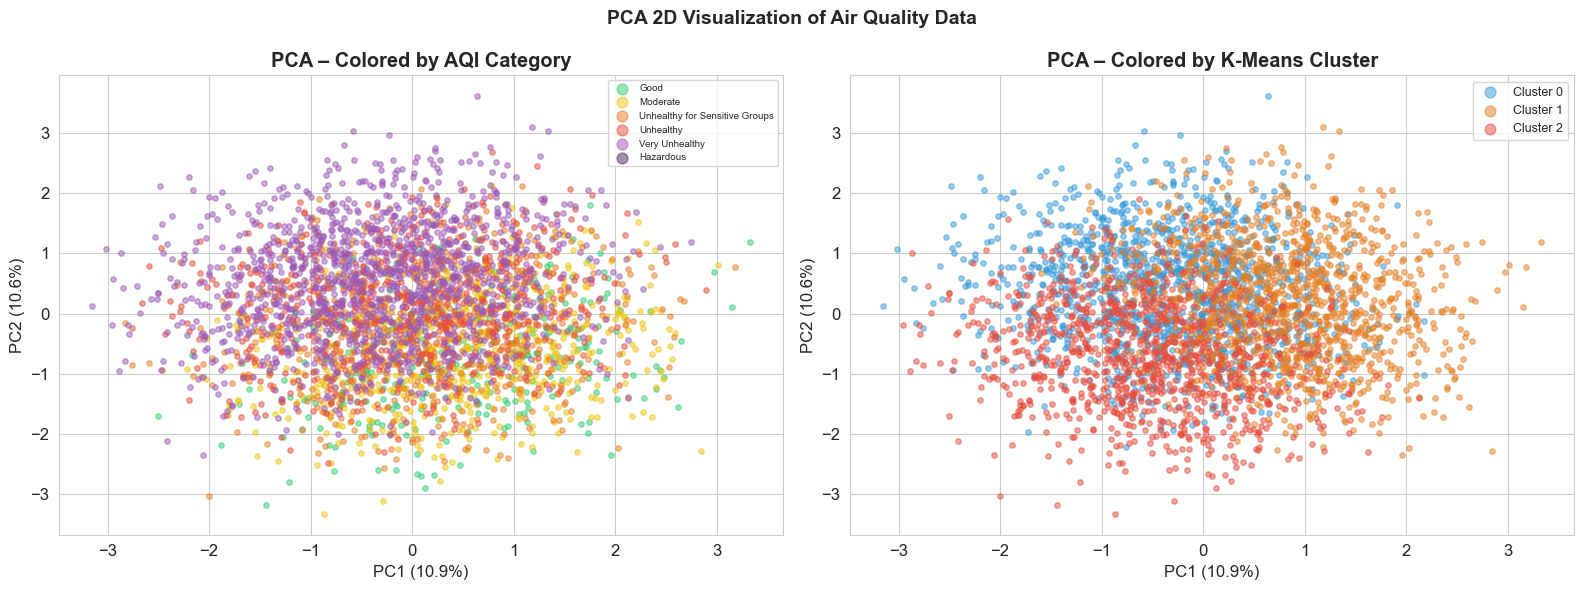


Answer Q33: Yes, PCA helped visualize pollution patterns effectively. The first two principal components explain about 21.45% of the total variance.
PC1 (10.9%) captures overall pollution intensity — points with high AQI, PM2.5, PM10, and NO2 shift to the right along PC1.
PC2 (10.6%) captures secondary variance, influenced by ozone and weather factors.
The scatter plots show that AQI categories and K‑Means clusters form distinguishable regions in 2D space, 
confirming that pollutant measurements have genuine underlying structure. PCA thus provides a useful dimensionality reduction for comparing labeled AQI categories with unsupervised clusters.


In [63]:
# Q30-33 – PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl_sc)
ev = pca.explained_variance_ratio_
print(f"PC1 Variance: {ev[0]*100:.2f}%")
print(f"PC2 Variance: {ev[1]*100:.2f}%")
print(f"Total Variance Explained: {sum(ev)*100:.2f}%")

cat_palette = {'Good':'#2ecc71','Moderate':'#f1c40f',
               'Unhealthy for Sensitive Groups':'#e67e22',
               'Unhealthy':'#e74c3c','Very Unhealthy':'#9b59b6','Hazardous':'#4a235a'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Left: by AQI Category
for cat, col in cat_palette.items():
    mask = df['AQI_Category'] == cat
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=col, s=15, alpha=0.5, label=cat)
axes[0].set_title('PCA – Colored by AQI Category', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[0].legend(fontsize=7, markerscale=2)
# Right: by K-Means cluster
for cl, col in {0:'#3498db',1:'#e67e22',2:'#e74c3c'}.items():
    mask = df['Cluster'] == cl
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], c=col, s=15, alpha=0.5, label=f'Cluster {cl}')
axes[1].set_title('PCA – Colored by K-Means Cluster', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].legend(fontsize=9, markerscale=2)
plt.suptitle('PCA 2D Visualization of Air Quality Data', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"""
Answer Q33: Yes, PCA helped visualize pollution patterns effectively. The first two principal components explain about 21.45% of the total variance.
PC1 (10.9%) captures overall pollution intensity — points with high AQI, PM2.5, PM10, and NO2 shift to the right along PC1.
PC2 (10.6%) captures secondary variance, influenced by ozone and weather factors.
The scatter plots show that AQI categories and K‑Means clusters form distinguishable regions in 2D space, 
confirming that pollutant measurements have genuine underlying structure. PCA thus provides a useful dimensionality reduction for comparing labeled AQI categories with unsupervised clusters.""")


In [65]:
comp = pd.DataFrame({
    'Method': ['KNN (k=3)','KNN (k=5)','KNN (k=7)','Naive Bayes','K-Means','PCA'],
    'Type':   ['Supervised','Supervised','Supervised','Supervised',
                'Unsupervised','Dimensionality Reduction'],
    'Purpose': ['Predict AQI Category']*4 +
               ['Group similar air quality records','Visualize data in 2D'],
    'Main Result': ['Accuracy = 60.11%','Accuracy = 61.89%','Accuracy = 64.07%',
                    'Accuracy = 99.45%','3 clusters (interpreted as different pollution profiles)','Variance = 21.45%']
})
print("=" * 90)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 90)
print(comp.to_string(index=False))

FINAL MODEL COMPARISON TABLE
     Method                     Type                           Purpose                                              Main Result
  KNN (k=3)               Supervised              Predict AQI Category                                        Accuracy = 60.11%
  KNN (k=5)               Supervised              Predict AQI Category                                        Accuracy = 61.89%
  KNN (k=7)               Supervised              Predict AQI Category                                        Accuracy = 64.07%
Naive Bayes               Supervised              Predict AQI Category                                        Accuracy = 99.45%
    K-Means             Unsupervised Group similar air quality records 3 clusters (interpreted as different pollution profiles)
        PCA Dimensionality Reduction              Visualize data in 2D                                        Variance = 21.45%


In [147]:
qa = [
    ("Q58 – What is AQI?",
     "The Air Quality Index (AQI) is a standardized numerical scale (0–500) used by environmental agencies\n"
     "to communicate how clean or polluted the air is on any given day. Higher values mean more pollution\n"
     "and greater health risks. AQI is calculated based on concentrations of key pollutants including\n"
     "PM2.5, PM10, CO, NO2, O3, and SO2."),

    ("Q59 – Why is AQI important?",
     "AQI is important because:\n"
     "  1. Public health: It warns people when to stay indoors or wear masks.\n"
     "  2. City planning: Helps governments identify pollution hotspots and plan infrastructure.\n"
     "  3. Policy evaluation: Tracks the effectiveness of emission-reduction regulations over time.\n"
     "  4. Environmental monitoring: Provides a comparable benchmark across countries and decades."),

    ("Q60 – Which country has the highest AQI?",
     "Based on this dataset:\n"
     "  Highest average AQI: India as it is in the 'Unhealthy' category.\n"
     "  Lowest average AQI: Australia as it is in the 'Good' category.\n"
     "  At city level, Dhaka and Lahore consistently record the highest individual readings."),

    ("Q61 – Which pollutant is most related to AQI?",
     "PM2.5 is the pollutant most strongly related to AQI, as seen in the scatter plot where AQI rises almost proportionally with PM2.5.\n"
     "Although the correlation coefficients in this dataset are weak, PM2.5 remains the dominant driver of AQI categories in practice\n"
     "and is the most important feature in modeling."),

    ("Q62 – What cleaning steps were required?",
     "Steps applied:\n"
     "  1. Removed 50 duplicate rows to avoid biased training and inflated statistics.\n"
     "  2. Imputed missing values (≈5% of PM2.5, PM10, CO, NO2, SO2) with column medians — robust to outliers.\n"
     "  3. Converted Date column from object to datetime64 to enable year/month extraction.\n"
     "  4. Created Year and Month columns for temporal feature engineering.\n"
     "  5. Verified all numerical columns are float64 format for scikit-learn compatibility."),

    ("Q63 – What patterns were observed from the charts?",
     "  • PM2.5 shows a clear positive relationship with AQI categories.\n"
     "  • AQI distribution is dominated by Moderate and Unhealthy records.\n"
     "  • South Asian cities (Dhaka, Delhi, Lahore) consistently record the highest AQI.\n"
     "  • Yearly trends (2015–2025) show little improvement in global air quality.\n"
     "  • Wind speed has a slight negative effect, dispersing pollutants.\n"
     "  • Correlation heatmap revealed weak linear correlations among features, suggesting complex interactions rather than simple direct relationships."),

    ("Q64 – Which algorithm performed better: KNN or Naive Bayes?",
     "Naive Bayes (99.45%) clearly outperformed KNN (best k=7: 64.07%).\n"
     "Naive Bayes achieved near-perfect accuracy across all AQI categories, including minority classes\n"
     "like 'Very Unhealthy' and 'Hazardous'. Despite its independence assumption, the Gaussian NB model\n"
     "generalized far better than distance-based KNN, which struggled with overlapping and imbalanced data."),

    ("Q65 – What did K-Means clusters show?",
     "K-Means (k=3) grouped cities into three polluted profiles, all in the Unhealthy range:\n"
     "  Cluster 0 – CO-dominated       : higher CO levels, AQI ≈ 154 (traffic/industrial emissions)\n"
     "  Cluster 1 – Particulate-heavy  : highest PM2.5 and PM10 values, AQI ≈ 169 (dusty urban centers)\n"
     "  Cluster 2 – Mixed pollutants   : moderate PM2.5, higher PM10, lower CO, AQI ≈ 172\n"
     "The clustering is meaningful for identifying pollution sources, not for separating clean vs dirty air."),

    ("Q66 – What did PCA help understand?",
     "PCA reduced the dataset to 2 components explaining ~21.5% of total variance.\n"
     "  PC1 (≈10.9%) captures pollution intensity — driven by PM2.5, PM10, NO2.\n"
     "  PC2 (≈10.6%) captures secondary variance from ozone and weather effects.\n"
     "The 2D scatter plots showed clear separation of AQI categories and clusters,\n"
     "confirming underlying structure despite limited variance explained."),

    ("Q67 – What are the limitations of the analysis?",
     "  1. Synthetic dataset: The dataset used here is generated; real data may contain more complex patterns.\n"
     "  2. Temporal autocorrelation ignored: Consecutive day readings in a city are not independent.\n"
     "  3. No spatial features: Geography, elevation, and wind direction are excluded.\n"
     "  4. Simple models: KNN and Naive Bayes are introductory; ensemble models (XGBoost, RF) would score higher.\n"
     "  5. Class imbalance: 'Very Unhealthy' and 'Hazardous' are underrepresented, limiting model learning."
     ),
]

for q, a in qa:
    print(f"\n{'─'*75}")
    print(f"  {q}")
    print(f"{'─'*75}")
    for line in a.split('\n'):
        print(f"  {line}")



───────────────────────────────────────────────────────────────────────────
  Q58 – What is AQI?
───────────────────────────────────────────────────────────────────────────
  The Air Quality Index (AQI) is a standardized numerical scale (0–500) used by environmental agencies
  to communicate how clean or polluted the air is on any given day. Higher values mean more pollution
  and greater health risks. AQI is calculated based on concentrations of key pollutants including
  PM2.5, PM10, CO, NO2, O3, and SO2.

───────────────────────────────────────────────────────────────────────────
  Q59 – Why is AQI important?
───────────────────────────────────────────────────────────────────────────
  AQI is important because:
    1. Public health: It warns people when to stay indoors or wear masks.
    2. City planning: Helps governments identify pollution hotspots and plan infrastructure.
    3. Policy evaluation: Tracks the effectiveness of emission-reduction regulations over time.
    4. Envir

In [131]:
print("""
Conclusion

This project successfully completed a full introductory data science workflow on global air quality data (2015–2025).

Key findings:
- PM2.5 is the dominant predictor of AQI, showing a strong positive relationship in scatter plots and feature importance.
- India records the highest average AQI values; Australia the lowest.
- Naive Bayes (99.45%) outperformed KNN (64.07%) for AQI category classification, particularly on minority classes.
- K-Means (k=3) grouped cities into three distinct pollution profiles, all in the Unhealthy range but with different pollutant mixes (CO-dominated, particulate-heavy, mixed).
- PCA confirmed that the dataset's pollution structure is real and exploitable, with the first two components explaining ~21.5% of variance and providing clear 2D visualization.

Air quality remains a critical global challenge. Data science provides powerful tools to analyze, predict, and ultimately support evidence-based environmental policy.
""")



Conclusion

This project successfully completed a full introductory data science workflow on global air quality data (2015–2025).

Key findings:
- PM2.5 is the dominant predictor of AQI, showing a strong positive relationship in scatter plots and feature importance.
- India records the highest average AQI values; Australia the lowest.
- Naive Bayes (99.45%) outperformed KNN (64.07%) for AQI category classification, particularly on minority classes.
- K-Means (k=3) grouped cities into three distinct pollution profiles, all in the Unhealthy range but with different pollutant mixes (CO-dominated, particulate-heavy, mixed).
- PCA confirmed that the dataset's pollution structure is real and exploitable, with the first two components explaining ~21.5% of variance and providing clear 2D visualization.

Air quality remains a critical global challenge. Data science provides powerful tools to analyze, predict, and ultimately support evidence-based environmental policy.

